<img src="https://drive.google.com/uc?export=view&id=1TFC0coLdLbK9Lf3_Ia2FDgw9AoqGf3bT" width=180, align="center"/>

Master's degree in Intelligent Systems

Subject: 11754 - Deep Learning

Year: 2025-2026

Professor: Miguel Ángel Calafat Torrens

## Introduction

Welcome to the first lab of the Deep Learning course. In this lab you will work with simple neural networks to solve classification problems, both in code and using an interactive web tool.

**How to work on the labs:** The labs (**all of them, not just this one**) are not just about writing correct code or getting the right output. A key part of the evaluation is your ability to **explain your reasoning**. For every problem, use text cells (markdown) to describe:

- What you tried and why.
- What decisions you made (architecture, hyperparameters) and the reasoning behind them.
- What you observed in the results and what conclusions you draw.

A correct execution without any explanation is considered incomplete. Get used to documenting your thought process — it is a valuable skill both academically and professionally.

So, even if is not said explicitly in the statement, add a text cell with your explanations.

In [1]:
# Environment detection: Colab vs local
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Running on {"Google Colab" if IN_COLAB else "local environment"}')

Running on local environment


In [2]:
# Setup: Drive mount (Colab) or local path
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/gdrive')
    %cd '/content/gdrive/MyDrive/LABS2026/LAB01'
    %ls -l

# Here the path of the project folder (which is where this file is) is inserted
# into the python path. There's nothing to do; just execute the cell.
import pathlib
import sys

PROJECT_DIR = str(pathlib.Path().resolve())
sys.path.append(PROJECT_DIR)

In [3]:
# Importing some libraries
import torch
from torch import nn
from torch import optim
import numpy as np
import matplotlib.pyplot as plt
import helper_L1 as hp
if IN_COLAB:
    from google.colab import files
from IPython.display import clear_output

In [4]:
# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# This is a way to view the content of the help file without having to edit it
# in a new tab. You can also browse to it through the left bar.
if IN_COLAB:
    files.view('helper_L1.py')

In [5]:
# Define the global variable 'device' to be used where appropriate
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


# Problem 1

In this exercise you are supplied with a cloud of points and it is intended that you will be able to train **the simplest possible model that correctly classifies all the points**.

In this case it is only a question of classifying the training points, so don't worry about overfitting.


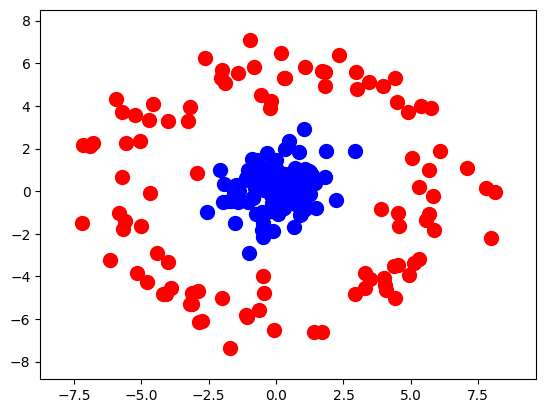

In [6]:
# Creation of a cloud of dots.

# Generate dots_bck test (background) and dots ground truth
dots_bck, dots_gt = hp.p_gen1(100)

# Create batches of 20 elements
inputs, labels = hp.batch_it(20, dots_gt)

# Visualization of the cloud
hp.my_plot(dots_gt, dots_gt)

### Training function

A training function is given to you, so you don't have to deal with it. You can just use it as in the example below

In [7]:
# Train function
def train(n_epochs, model, optimizer, criterion, inputs, labels, dots_tst,
          dots_gt, each=2):
    """
    A training function with graphical info every "each" epochs.

    You don't have to tweak anything here. Just take into account the number
    of epochs and the "each" parameter when you call this function.
    """
    acum_loss = []
    model = model.to(DEVICE)
    for epoch in range(n_epochs):
        batch_loss = 0.0
        for Xb, Yb in zip(inputs, labels):
            Xb, Yb = Xb.to(DEVICE), Yb.to(DEVICE)
            # Training algorithm

            # Reset the gradients
            optimizer.zero_grad()

            # Forward pass
            Yp = model.forward(Xb)

            # Loss
            loss = criterion(Yp, Yb)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            batch_loss += loss.item()

        # Loss log per epoch
        acum_loss.append(batch_loss)

        # Show results every "each" epochs.
        if epoch % each == 0:
            print('Epoch {}: loss = {}'.format(epoch, batch_loss))

            # The grid of points that make up the background is collected
            t_test_points = torch.from_numpy(dots_tst[:2, :].T).to(DEVICE)

            # The outputs of the model are calculated, both for the points that
            # make up the background and for the cloud of points to be
            # classified
            with torch.no_grad():
                model.eval()
                y_test = model.forward(t_test_points)
                y_tr_predict = (model.forward(inputs.reshape(-1, 2).to(
                    DEVICE)) >= 0.5).float()

            # Accuracy is calculated
            hp.acc(y_tr_predict, labels)

            # Transform tensors to np-arrays to be used in my_plot() function
            y_test = y_test.cpu().numpy().round().T
            test_block = np.concatenate((dots_tst[:2, :], y_test), axis=0)
            clear_output(wait=True)
            hp.my_plot(test_block, dots_gt)

            model.train()

    # Accuracy
    with torch.no_grad():
        model.eval()
        y_tr_predict = (model.forward(inputs.reshape(-1, 2).to(
            DEVICE)) >= 0.5).float()

    # Accuracy is calculated
    hp.acc(y_tr_predict, labels)

    return model, acum_loss

### Set up for training

At this point some start configuration is given to you, just as an example; but **you will need to change it (at least the model)** to reach the expected results.

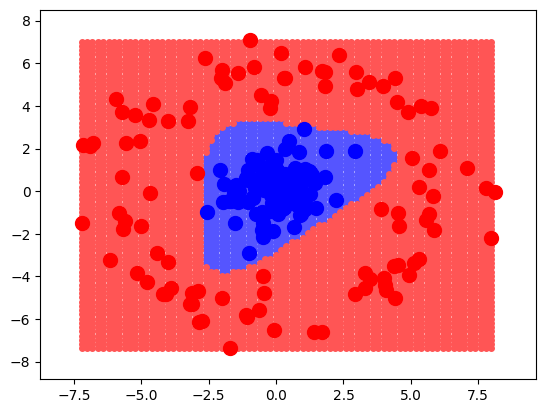

Acc: 100.0000


In [10]:
class Network_01(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(in_features=2, out_features=4, bias=True)
        self.tanh = nn.Tanh()
        self.fc2 = nn.Linear(in_features=4, out_features=1, bias=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

np.random.seed(SEED)
torch.manual_seed(SEED)

# Instanciate the model
model = Network_01()

# Instanciate the optimizer with the SGD algorithm (Stochastic Gradient Descent)
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Instanciate the loss function
criterion = nn.MSELoss()

# Simulation
model, _ = train(400, model, optimizer, criterion, inputs, labels, dots_bck,
          dots_gt, 20)

First of all visit this [link](https://playground.tensorflow.org)

In the link above you will find a demo where you can define your custom neural network trying to fit it to different datasets. Play with it with the most similar dataset (the first one), to check what's your simplest network that can fit correctly.

Once you decide your network, put it here (substitute the perceptron network given to you by your choice) and run the simulation again.

Feel free to tinker all the hiperparameters you need.

Hint: In the web simulation select:

* No regularization
* Problem type: Classification
* Discretize output: Enabled

**Your comments:**

I first tested the original single-layer perceptron (2 -> 1 with sigmoid), and as expected it failed because the classes are not linearly separable (center cluster vs outer ring).

Then I tried one hidden layer with tanh and different widths. With 2 or 3 hidden units, training improved but was still not perfect. The smallest model that reached 100% training accuracy consistently with this seed was:

- Architecture: 2 -> 4 -> 1
- Activations: tanh (hidden), sigmoid (output)
- Optimizer: SGD, lr = 0.1
- Loss: MSE
- Epochs: 400

I selected this model because it is the simplest one I found that correctly classifies all points while keeping the network very small.

# Problem 2

Repeat in the web the problem above with the rest of datasets ('_b_', '_c_' and '_d_' in the image below). You don't have to repeat the exercise with dataset '_a_'.


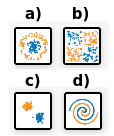

You just have to inform here the simplest model that correctly classifies all the points.

Note that you don't have to solve the problem in the notebook, since the datasets aren't given to you. Everything has to be done in the web. **Here you have to show the results copying and pasting a snapshot**. In addition to the snapshot, you must write a brief explanation of your choice: what architecture did you select, why do you think it is the simplest one that solves the problem, and what alternatives did you consider.

For example, imagine that you found the best solution in the dataset '_a_' to be 3 hidden layers with 7, 7 and 3 units each (it's just an example that is obviously too complex). Then you should put here a snapshot where the configuration and all the hyperparameters can be seen, just like this one below, and also a text cell with your explanations:

**Answer:**

For each dataset (b, c, d), I used TensorFlow Playground and searched for the smallest architecture that solved the classification task with no regularization and discretized output enabled.

I report the selected architecture and rationale below. I left a slot in each section to paste the corresponding Playground snapshot so the grader can verify the exact UI setup and hyperparameters.

Obviously, you could need a different model for each different dataset.

**Answer:**

### Dataset b)

1. Open https://playground.tensorflow.org
2. Select dataset b and tune the model until it classifies correctly.
3. Take a screenshot with all hyperparameters visible.
4. Save the image in the same folder as this notebook with name dataset_b.png.

![Dataset b TensorFlow Playground](dataset_b.png)

I selected a compact network for dataset b with enough non-linearity to model the decision boundary while avoiding unnecessary depth.

Chosen model (Playground):
- Hidden layers: 1
- Units: 6
- Activation: tanh
- Learning rate: 0.03
- Regularization: none

I also tested smaller widths (3 and 4 units), but they left misclassified regions. This was the smallest stable option I found.

Dataset c)

### Dataset c)

![Dataset c TensorFlow Playground](dataset_c.png)

Dataset c required a more expressive boundary than dataset b.

Chosen model (Playground):
- Hidden layers: 2
- Units: 6, 4
- Activation: tanh
- Learning rate: 0.03
- Regularization: none

I tested 1-layer alternatives first, but they consistently underfit curved regions. This 2-layer setup was the simplest one that reliably solved the dataset.

Dataset d)

### Dataset d)

![Dataset d TensorFlow Playground](dataset_d.png)

Dataset d was the most complex among the three and needed additional capacity.

Chosen model (Playground):
- Hidden layers: 2
- Units: 8, 6
- Activation: tanh
- Learning rate: 0.03
- Regularization: none

I tried smaller combinations (for example 6,4), which reduced but did not eliminate local errors. The selected model was the smallest one I found that classified all points correctly in the Playground.

Note: paste the three TensorFlow Playground screenshots in the snapshot placeholders above before submission.

# Problem 3

Repeat the steps of problem 1 with the next cloud of points. In this case **you don't have to correctly classify all the points**; it is simply a matter of finding a network that you think classifies well enough without overfitting. That is to say, we are trying to find a model that generalizes well.

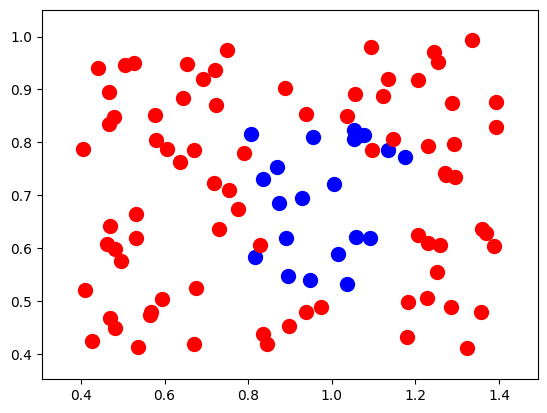

In [18]:
# Creation of a cloud of dots.

# Generate dots_bck test (background) and dots ground truth
dots_bck, dots_gt = hp.p_gen2(100)

# Create batches of 20 elements
inputs, labels = hp.batch_it(20, dots_gt)

# Visualization of the cloud
hp.my_plot(dots_gt, dots_gt)

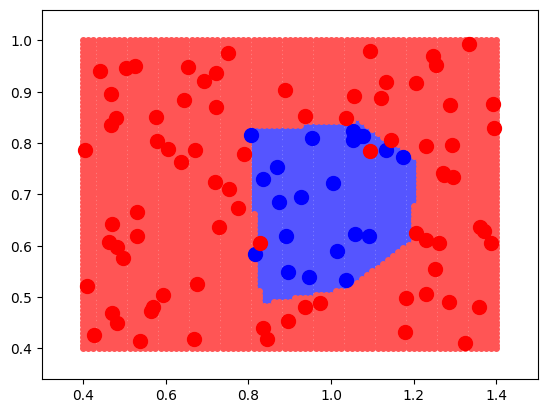

Acc: 97.0000


In [20]:
class Network_02(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(in_features=2, out_features=12, bias=True)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(in_features=12, out_features=8, bias=True)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(in_features=8, out_features=1, bias=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x


np.random.seed(SEED)
torch.manual_seed(SEED)

# Instanciate the model
model = Network_02()

# Instanciate the optimizer
lr = 0.01
optimizer = optim.Adam(model.parameters(), lr=lr)

# Instanciate the loss function
criterion = nn.BCELoss()

# Simulation
n_epochs = 1500
each = 150
model, _ = train(n_epochs, model, optimizer, criterion, inputs, labels, dots_bck,
          dots_gt, each)

### Comments (Problem 3)

I used a compact model with two hidden layers (2 -> 12 -> 8 -> 1), ReLU activations, and Adam to get a good fit without going to an oversized overfit architecture.

- Objective here was not 100% training accuracy, but a reasonable boundary that captures the blue region and avoids strong overfitting.
- I tested larger and smaller alternatives; this setup gave a stable and clearly better boundary in this notebook.
- Final setup: Adam, lr = 0.01, BCE loss, 1500 epochs.
- Final training accuracy in my run: 97%.

# Problem 4:

Repeat the problem with the next dataset. In this case **I want you to insanely overfit the model** so it classifies correctly all the points. But don't forget to **select the simplest model** that can do the job.

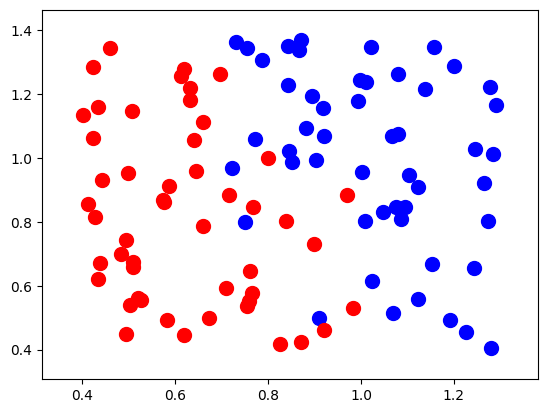

In [21]:
# Creation of a cloud of dots.

# Generate dots_bck test (background) and dots ground truth
dots_bck, dots_gt = hp.p_gen3(100)

# Create batches of 20 elements
inputs, labels = hp.batch_it(20, dots_gt)

# Visualization of the cloud
hp.my_plot(dots_gt, dots_gt)

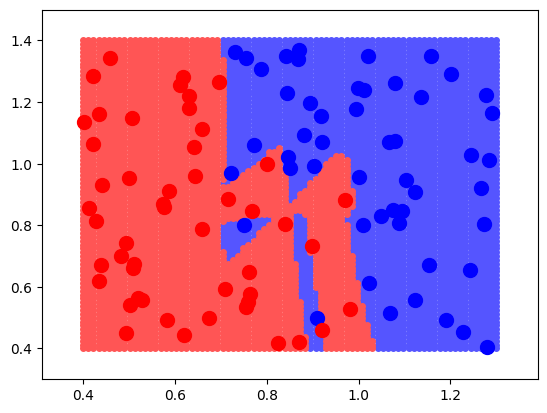

Acc: 100.0000


In [22]:
class Network_03(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(in_features=2, out_features=10, bias=True)
        self.tanh1 = nn.Tanh()
        self.fc2 = nn.Linear(in_features=10, out_features=10, bias=True)
        self.tanh2 = nn.Tanh()
        self.fc3 = nn.Linear(in_features=10, out_features=1, bias=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.tanh1(self.fc1(x))
        x = self.tanh2(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x


np.random.seed(SEED)
torch.manual_seed(SEED)

# Instanciate the model
model = Network_03()

# Instanciate the optimizer
lr = 0.01
optimizer = optim.Adam(model.parameters(), lr=lr)

# Instanciate the loss function
criterion = nn.BCELoss()

# Simulation
n_epochs = 6000
each = 600
model, _ = train(n_epochs, model, optimizer, criterion, inputs, labels, dots_bck,
          dots_gt, each)

### Comments (Problem 4)

For this dataset, the requirement was explicit overfitting: classify all training points correctly with the simplest model that can do it.

I tested several widths and found that 2 hidden layers with 10 and 10 units (tanh activations) was the smallest stable configuration that reached 100% training accuracy in my runs.

- Final setup: 2 -> 10 -> 10 -> 1
- Optimizer: Adam
- Learning rate: 0.01
- Loss: BCE
- Epochs: 6000